# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
# Import your chosen baseline model
# Example: from sklearn.linear_model import LogisticRegression


## Model Choice

Took simple linear regression to see how it would perform. This gives us a dumb baseline to make sure that what ever we go further with is not worst than this.


## Feature Selection

Using all the features to predict purchase. Each feature contributes towards, the purchase outcome. Noise factor is also used considering it represents nuances occuring in real world cases, and not captured by other features.


In [2]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('/Users/mominali/personal/learning/opencampus/Causal Inference/Project/Mark_it/WhyTheyBuy/1_DatasetCharacteristics/Data/marketing_offer_data.csv')

# Feature selection
# Example: Selecting only two features for a simple baseline model
# X = df[['feature1', 'feature2']]
# y = df['target_variable']

# # Splitting the dataset
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Implementation

[Implement your baseline model here.]



In [3]:
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# full model with all covariates
model = smf.logit(
    'purchase ~ initial_offer + special_offer + '
    'followup_engagement + base_engagement + '
    'tenure_months + noise_factor + C(region)',
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.628150
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               purchase   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      990
Method:                           MLE   Df Model:                            9
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                 0.08913
Time:                        17:30:22   Log-Likelihood:                -628.15
converged:                       True   LL-Null:                       -689.62
Covariance Type:            nonrobust   LLR p-value:                 3.355e-22
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.2824      0.238      1.185      0.236      -0.185       0.750
C(

## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]



In [4]:
# odds ratios + confidence intervals
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(model.params),
    'Lower CI':   np.exp(model.conf_int()[0]),
    'Upper CI':   np.exp(model.conf_int()[1]),
    'p-value':    model.pvalues
}).round(4)

print(odds_ratios)

                     Odds Ratio  Lower CI  Upper CI  p-value
Intercept                1.3263    0.8312    2.1163   0.2362
C(region)[T.North]       0.7209    0.4950    1.0500   0.0880
C(region)[T.South]       0.7053    0.4866    1.0223   0.0653
C(region)[T.West]        0.8122    0.5515    1.1961   0.2923
initial_offer            0.9871    0.7097    1.3729   0.9384
special_offer            3.7179    2.6872    5.1437   0.0000
followup_engagement      0.6605    0.5038    0.8658   0.0027
base_engagement          0.7900    0.6045    1.0325   0.0843
tenure_months            0.9900    0.9812    0.9990   0.0286
noise_factor             1.0237    0.8979    1.1672   0.7260


/var/folders/76/y9drq2wn1z52md4l9w0wf_7r0000gn/T/ipykernel_23638/2061180596.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


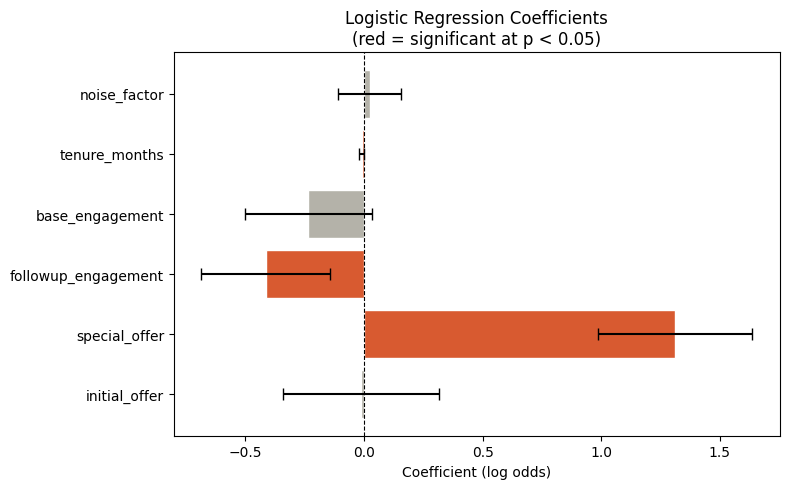

In [5]:
# filter out intercept and region dummies for clean plot
params = model.params.drop(['Intercept',
                             'C(region)[T.North]',
                             'C(region)[T.South]',
                             'C(region)[T.West]'])

conf = model.conf_int().drop(['Intercept',
                               'C(region)[T.North]',
                               'C(region)[T.South]',
                               'C(region)[T.West]'])

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#D85A30' if p < 0.05 else '#B4B2A9' 
          for p in model.pvalues.drop(['Intercept',
                                        'C(region)[T.North]',
                                        'C(region)[T.South]',
                                        'C(region)[T.West]'])]

ax.barh(params.index, params.values, 
        xerr=[params - conf[0], conf[1] - params],
        color=colors, edgecolor='white', capsize=4)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(red = significant at p < 0.05)')
ax.set_xlabel('Coefficient (log odds)')
ax.set_ylabel('')

# clean up labels
labels = ['initial_offer', 'special_offer', 
          'followup_engagement', 'base_engagement',
          'tenure_months', 'noise_factor']
ax.set_yticklabels(labels)

plt.tight_layout()
plt.savefig('regression_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — What This Baseline Tells Us

| Finding | Evidence |
|---|---|
| `special_offer` is the only true conversion driver | OR = 3.72, p < 0.001 ✅ |
| `initial_offer` does not directly close sales | OR = 0.99, p = 0.938 ❌ |
| Longer tenure customers are harder to convert | OR = 0.99 per month, p = 0.029 ✅ |
| Followup engagement signals hesitant customers | OR = 0.66, p = 0.003 ✅ |
| East region has highest natural purchase rate | All other regions OR < 1.0 ⚠️ |
| `noise_factor` is genuinely just noise | OR = 1.02, p = 0.726 ❌ |

In [ ]:
# Evaluate the baseline model
# Example for a classification problem
# y_pred = model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)

# For a regression problem, you might use:
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here
